# Paper Walkthrough 
- intro
    - paper:A Neural Probabilistic Language Model, Bengio et al. 2003 (MLP language model)
    - 17,000 vocab -> 30 dimensional space (each) (**world embedding**)
    - previous word -> next word predict 
    - maximize the log-likehood of the training data
- model architecture  
    ![Architecture](./Neural_architecture.png)
    - Input Layer: 이전 $n$개의 단어(문맥)를 가져옴
    - Embedding Layer: 각 단어를 벡터로 변환하고 모두 일렬로 이어 붙임(Concatenation).
        - 문맥 내 모든 단어는 동일한 임베딩 행렬(C)를 공유함.
    - Hidden Layer: tanh 활성화 함수를 사용하는 은닉층을 통과시켜 복잡한 관계를 학습.
    - Output Layer: Softmax를 통해 다음 단어가 무엇이 될지 확률을 출력.

# Building Dataset & layer

In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
# read in all the worlds 
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers 
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset 

block_size = 3 # context length: how many characters do we take to predict the next one? 
X, Y = [], [] # X:input, Y:label

for w in words[:5]:
    print(w)    
    context = [0] * block_size # 처음에는 아무 정보가 없으므로 0(패딩 토큰 .)으로 채워진 리스트로 싲가
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context) # 현재 문맥
        Y.append(ix)      # 정답(지금 나타난 글자: ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append (가장 오래된 기억 제거)
        
X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [ ]:
# implement the embedding lookup table example

C = torch.randn((27,2)) # 파이썬의 튜플 자료형을 하나의 덩어리로 넘김 
C

tensor([[-1.2074, -0.6819],
        [-0.0201,  0.4377],
        [-1.2932, -1.0602],
        [-1.6826, -0.6972],
        [-2.2537, -0.9920],
        [-2.5202,  0.6528],
        [ 1.3374, -2.1187],
        [ 0.8878, -1.0466],
        [ 0.9441, -0.3453],
        [-0.0463, -0.4985],
        [-0.7625,  0.6403],
        [-1.2783,  1.1895],
        [-0.1516,  1.3469],
        [ 0.0938, -0.6619],
        [ 1.1094,  1.6298],
        [-1.1304, -0.5342],
        [-1.5197,  0.8920],
        [-1.2792,  1.4115],
        [ 0.2499,  0.0323],
        [-1.7123, -1.4173],
        [-0.6744,  0.2330],
        [-0.2092,  0.8879],
        [ 1.5516, -0.4604],
        [-0.0567, -0.8535],
        [-1.3990,  0.5292],
        [-0.6579,  0.5741],
        [-0.7652,  1.2142]])

In [9]:
C[5]

tensor([-2.5202,  0.6528])

In [11]:
C[X].shape

torch.Size([32, 3, 2])

In [20]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [ ]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

# emb @ W1 + b1 : 신경망 연산 
# W1이 2차원이기 때문에 emb와 W1을 @(행렬곱)하려면 emb의 차원수를 맞춰줘야 함

In [22]:
emb[:, 0, :].shape # 첫번째 단어의 임베딩

torch.Size([32, 2])

In [25]:
# emb의 차원 수를 맞추는 방법
# 1. concat(torch.cat): dimension(=1)방향으로 이어붙여서 shape 변경 가능 But!! block_size가 3이라 코드를 3번 썼지만 block_size를 변경하면 코드를 늘려야 함
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape # 1=dimension

# 2. unbind: 특정 차원을 기준으로 텐서를 낱개로 분리하여 리스트로 반환 But!! 메모리 낭비
torch.cat(torch.unbind(emb, 1), 1).shape  # unbind(emb, 1): 1=emb의 shape 중 1번째([32,3,2] 중 3)을 기준으로 텐서 분리 => [32,2]shape 텐서 3개가 들어있는 리스트 생성([tensor 0, tensor 1, tensor 2])
                                          # cat(): [32,2]를 나란히 붙힘
                                          
# 3. view: Storage는 전혀 건드리지 않고, Metadata(읽는 방법)만 변경
#           - Storage: 데이터가 메모리상에 일렬(1D)로 쭉 늘어서 있는 실제 저장 공간
#           - View(Metadata): 일렬로 된 데이터를 몇 행 몇 열로 읽을 것인가에 대한 정보(shape, stride)
# 메모리에는 [32,3,2] 텐서가 192(32*3*2)개의 1D로 저장되어 있음
# 원래 모양 = [32,3,2] 즉, 숫자를 2개씩 묶어서 단어를 만들고, 그 단어를 3개씩 묶어서 문장을 만들어라
# view(32,6) = 숫자를 6개씩 묶어서 하나의 문장을 ㅗ만들어라

emb.view(-1, 6) #-1: 나머지 차원은 알아서 계산할 것!

tensor([[-1.2074, -0.6819, -1.2074, -0.6819, -1.2074, -0.6819],
        [-1.2074, -0.6819, -1.2074, -0.6819, -2.5202,  0.6528],
        [-1.2074, -0.6819, -2.5202,  0.6528,  0.0938, -0.6619],
        [-2.5202,  0.6528,  0.0938, -0.6619,  0.0938, -0.6619],
        [ 0.0938, -0.6619,  0.0938, -0.6619, -0.0201,  0.4377],
        [-1.2074, -0.6819, -1.2074, -0.6819, -1.2074, -0.6819],
        [-1.2074, -0.6819, -1.2074, -0.6819, -1.1304, -0.5342],
        [-1.2074, -0.6819, -1.1304, -0.5342, -0.1516,  1.3469],
        [-1.1304, -0.5342, -0.1516,  1.3469, -0.0463, -0.4985],
        [-0.1516,  1.3469, -0.0463, -0.4985,  1.5516, -0.4604],
        [-0.0463, -0.4985,  1.5516, -0.4604, -0.0463, -0.4985],
        [ 1.5516, -0.4604, -0.0463, -0.4985, -0.0201,  0.4377],
        [-1.2074, -0.6819, -1.2074, -0.6819, -1.2074, -0.6819],
        [-1.2074, -0.6819, -1.2074, -0.6819, -0.0201,  0.4377],
        [-1.2074, -0.6819, -0.0201,  0.4377,  1.5516, -0.4604],
        [-0.0201,  0.4377,  1.5516, -0.4

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

# 여기서 broadcasting
# [32,100]과 [100]의 벡터를 더해야 함
# Broadcating을 통해 [100]을 [1,100]으로 자동으로 간주하고, 32개의 데이터에 [1,100]을 복사하여 [32,100]으로 늘린 뒤 요소합을 진행함

In [29]:
h

tensor([[ 0.9973, -0.9856, -0.0396,  ..., -0.9904,  1.0000,  0.5563],
        [ 0.9908, -0.7020,  0.7316,  ..., -0.9692,  0.9966,  0.5998],
        [-0.7674, -1.0000, -0.4739,  ..., -0.9832,  0.9999, -0.9943],
        ...,
        [-0.9882, -0.9998, -0.0648,  ..., -0.4359,  0.9997, -0.9810],
        [ 0.9537, -0.7732,  0.4087,  ..., -0.6487,  0.5998,  0.9861],
        [-0.3426,  0.3645,  0.9998,  ...,  0.3195,  0.9882, -0.3705]])

In [30]:
h.shape

torch.Size([32, 100])

In [ ]:
# 특징(100) -> 글자(27)
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [32]:
logits = h @ W2 + b2

In [33]:
logits.shape

torch.Size([32, 27])

In [ ]:
# 점수 -> 확률 (softmax)
counts = logits.exp() # 지수화
prob = counts / counts.sum(1, keepdims=True) # 정규화 (Pytorch의 dim 인자는 **어떤 차원을 따라가며 합쳐서 그 차원을 없앨지** 결정. 즉, dim=0은 세로(행)방향으로 더하는 거라 열별 합계)

In [37]:
prob.shape

torch.Size([32, 27])

In [40]:
prob[torch.arange(32),Y]

tensor([1.2839e-02, 2.9071e-02, 8.3258e-02, 5.5149e-07, 1.2108e-04, 2.4864e-05,
        2.4337e-07, 1.3392e-10, 3.5332e-08, 1.2725e-08, 4.3031e-08, 1.6481e-02,
        3.2013e-01, 7.2892e-06, 9.2271e-11, 7.0930e-05, 3.6233e-11, 6.2766e-08,
        1.0685e-04, 9.3813e-01, 4.2748e-04, 6.9769e-06, 1.0468e-14, 9.0061e-11,
        5.7836e-08, 3.3377e-07, 5.1410e-10, 6.9416e-08, 1.9805e-06, 1.2156e-06,
        6.8334e-10, 1.0956e-03])

In [41]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(13.5411)

# MLP

In [55]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [61]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((27, 2), generator=g, requires_grad=True) 
W1 = torch.randn((6, 100), generator=g, requires_grad=True) 
b1 = torch.randn(100, generator=g, requires_grad=True) 
W2 = torch.randn((100, 27), generator=g, requires_grad=True) 
b2 = torch.randn(27, generator=g, requires_grad=True) 
parameters = [C, W1, b1, W2, b2]

In [62]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [63]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()

In [64]:
# Cross entropy
F.cross_entropy(logits, Y)
# F.cross_entropy == counts = logits.exp()
#                    prob = counts / counts.sum(1, keepdims=True)
#                    loss = -prob[torch.arange(32), Y].log().mean()
# cross_entrorpy의 장점 = forward pass가 더 효율적이고, backward pass도 효율적, 수치적으로 안정적
#   - cross_entropy는 중간 계산에서 사용하는 메모리를 사용하지 않고 더 효율적임 
#   - logits.exp()는 x가 조금만 커져도 값이 폭발적으로 증가 -> overflow But cross_entropy 는 내부적으로 x에서 최대값을 빼주기 때문에 수학적으로 결과는 같지만, 지수 부분에 큰 양수가 오는 것을 막음

tensor(17.7697, grad_fn=<NllLossBackward0>)

In [67]:
for _ in range(10):
    # forward pass
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

1.1833815574645996


# large hidden layer

In [68]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [69]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [70]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [71]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [72]:
for p in parameters:
  p.requires_grad = True

In [73]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [74]:
lri = []
lossi = []
stepi = []

In [75]:
for i in range(2000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

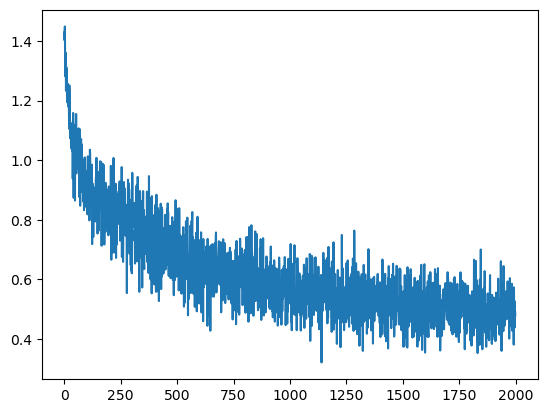

In [76]:
plt.plot(stepi, lossi)

In [77]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(3.0597, grad_fn=<NllLossBackward0>)

In [78]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(3.0526, grad_fn=<NllLossBackward0>)

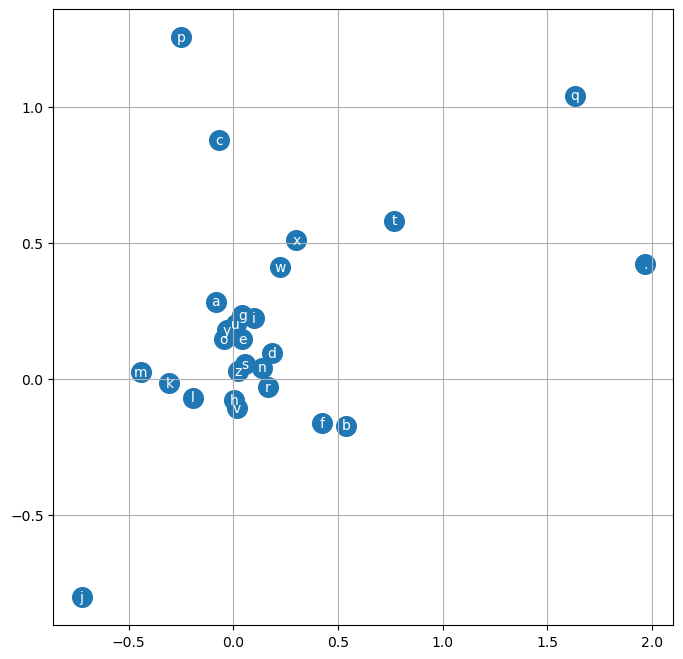

In [79]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')